In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

In [2]:
#相对路径读取data文件夹下的数据
df = pd.read_csv("./data/movie_comments.csv")

print("====基础实践：读取数据集====")
print(f"数据集shape：{df.shape}")
print("全部列名：", df.columns.tolist())
print("\n前5行原始数据：")
print(df.head())

====基础实践：读取数据集====
数据集shape：(30, 2)
全部列名： ['comment', 'label']

前5行原始数据：
                 comment  label
0       画面质感非常高级，观影体验极佳。      1
1  这部电影的剧情节奏紧凑，全程没有多余桥段。      1
2     演员演技自然细腻，人物塑造非常立体。      1
3       整体镜头语言很舒服，氛围感拉满。      1
4     剧情反转出乎意料，看完让人回味无穷。      1


In [3]:
print("\n====各类别样本数量====")
print(df["label"].value_counts())

#新增text_len列，计算每条评论字符长度
df["text_len"] = df["comment"].apply(lambda x: len(str(x)))

print("\n====文本长度统计（最小、均值、中位数、最大）====")
print(df["text_len"].describe()[["min","mean","50%","max"]])


====各类别样本数量====
label
1    22
0     8
Name: count, dtype: int64

====文本长度统计（最小、均值、中位数、最大）====
min     14.000000
mean    16.766667
50%     16.000000
max     21.000000
Name: text_len, dtype: float64


In [4]:
print("\n====检查空值====")
print(df.isna().sum())

dup_count = df.duplicated().sum()
print(f"\n重复样本数量：{dup_count}")

df = df.drop_duplicates()
print(f"去重之后样本数量：{len(df)}")


====检查空值====
comment     0
label       0
text_len    0
dtype: int64

重复样本数量：0
去重之后样本数量：30


In [6]:
print("\n==== label=0 随机5条 ====")
print(df[df["label"]==0]["comment"].sample(5).tolist())

print("\n==== label=1 随机5条 ====")
print(df[df["label"]==1]["comment"].sample(5).tolist())


==== label=0 随机5条 ====
['结尾留白太多，让人感觉意犹未尽。', '节奏偏慢，部分片段略显拖沓冗长。', '配角戏份太少，人物刻画不够饱满。', '部分情节铺垫不足，转折稍微有些突兀。', '部分剧情逻辑漏洞较多，影响观感。']

==== label=1 随机5条 ====
['配乐搭配画面恰到好处，情绪渲染很到位。', '结局处理温柔治愈，让人内心很温暖。', '整体镜头语言很舒服，氛围感拉满。', '笑点和泪点结合得很好，观影体验丰富。', '情感表达真挚动人，很容易产生共鸣。']


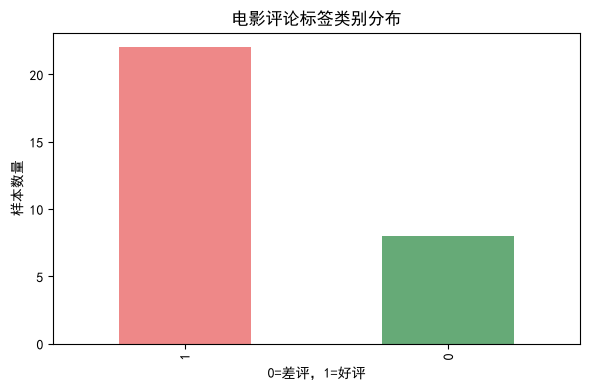

In [7]:
plt.figure(figsize=(6,4))
df["label"].value_counts().plot(kind="bar",color=["#ee8888","#66aa77"])
plt.title("电影评论标签类别分布")
plt.xlabel("0=差评，1=好评")
plt.ylabel("样本数量")
plt.tight_layout()
plt.savefig("./label_dist.png",dpi=150)
plt.show()

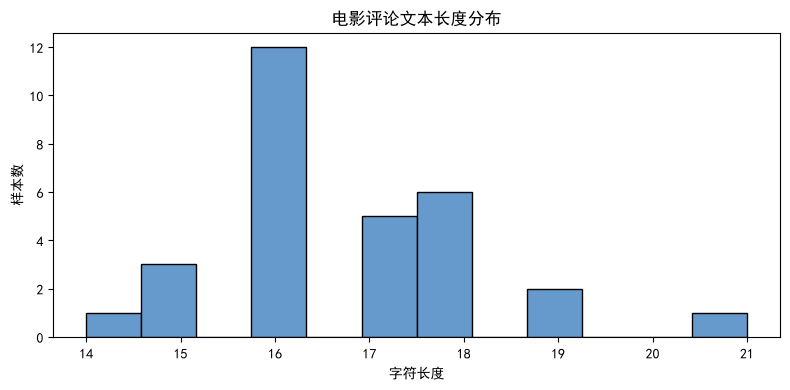

In [8]:
plt.figure(figsize=(8,4))
plt.hist(df["text_len"],bins=12,color="#6699cc",edgecolor="black")
plt.title("电影评论文本长度分布")
plt.xlabel("字符长度")
plt.ylabel("样本数")
plt.tight_layout()
plt.savefig("./text_length_dist.png",dpi=150)
plt.show()

In [9]:
print("\n====5条最短的评论文本====")
print(df.sort_values("text_len").head(5)[["comment","label","text_len"]])

print("\n====5条最长的评论文本====")
print(df.sort_values("text_len",ascending=False).head(5)[["comment","label","text_len"]])


====5条最短的评论文本====
             comment  label  text_len
18    特效制作精良，大片质感十足。      1        14
6    故事立意深刻，看完有很多思考。      1        15
16   剧情套路比较常见，缺少惊喜感。      0        15
21   叙事方式独特，观影体验很新鲜。      1        15
12  打斗场面精彩震撼，视觉效果满分。      1        16

====5条最长的评论文本====
                  comment  label  text_len
1   这部电影的剧情节奏紧凑，全程没有多余桥段。      1        21
5     配乐搭配画面恰到好处，情绪渲染很到位。      1        19
25    整体完成度很高，是一部值得二刷的电影。      1        19
4      剧情反转出乎意料，看完让人回味无穷。      1        18
8      人物动机交代不够清晰，逻辑略有瑕疵。      0        18


In [10]:
print("\n====Numpy向量、矩阵演示====")
#一维向量
vec = np.array([42,55,31,67])
print("一维向量：",vec)
print("向量shape：",vec.shape)
print("向量：一维，一组数字\n")

#二维矩阵
mat = np.array([[2,4,6],
                [1,3,5],
                [7,8,9]])
print("矩阵：\n",mat)
print("矩阵shape：",mat.shape)
print("矩阵shape格式(行数,列数)，第一维行数，第二维列数")


====Numpy向量、矩阵演示====
一维向量： [42 55 31 67]
向量shape： (4,)
向量：一维，一组数字

矩阵：
 [[2 4 6]
 [1 3 5]
 [7 8 9]]
矩阵shape： (3, 3)
矩阵shape格式(行数,列数)，第一维行数，第二维列数


In [11]:
df_clean = df[df["text_len"] >=10].copy()
print(f"清洗前 {len(df)}，清洗后 {len(df_clean)}")

df_clean.to_csv("./data/movie_clean.csv",index=False,encoding="utf-8")
print("已保存清洗后数据 data/movie_clean.csv")

清洗前 30，清洗后 30
已保存清洗后数据 data/movie_clean.csv


In [12]:
def check_data(df):
    print("====自动数据质量检查====")
    print("空值统计：")
    print(df.isna().sum())
    print(f"重复样本：{df.duplicated().sum()}")

check_data(df)

====自动数据质量检查====
空值统计：
comment     0
label       0
text_len    0
dtype: int64
重复样本：0
